# 실습 5·6 — HuggingFace Vision 사전학습 모델 (3교시)

**학습 목표**
- 사전학습 모델과 ViT(Vision Transformer)의 핵심 아이디어를 이해한다.
- `pipeline("image-classification")` 1줄로 ImageNet 분류를 수행한다.
- 본인 휴대폰 사진을 직접 분류하고 top-5 확률을 해석한다.
- 분류 실패 사례를 모아 12주차 파인튜닝의 동기를 발견한다.

**사전 조건**
```
pip install torch torchvision transformers datasets pillow matplotlib
```
- 1·2교시 실습 완료 권장 (전처리·증강 개념 이해)
- `sample_images/dog.jpg`, `cat.jpg`, `landscape.jpg` 존재
- (선택) 본인 휴대폰 사진을 `sample_images/` 또는 노트북 폴더에 업로드


## 셀 [0] — 한글 폰트 + 공통 import

In [3]:
import platform
import matplotlib.pyplot as plt
from matplotlib import rcParams

if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False

## 셀 [1] — `pipeline`으로 ViT 로드

첫 실행 시 약 330MB 다운로드 (1~3분). 다음부터는 캐시에서 즉시 로드.
**환경 자동 감지**: GPU가 있으면 GPU, 없으면 CPU.

In [4]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

classifier = pipeline(
    task="image-classification",
    model="google/vit-base-patch16-224",
    device=device,
)

print(f"✅ ViT 모델 로드 완료 (실행 장치: {'GPU' if device == 0 else 'CPU'})")

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 7366.31it/s]


✅ ViT 모델 로드 완료 (실행 장치: CPU)


## 셀 [2] — 샘플 이미지로 첫 분류

`classifier(img, top_k=5)` → `[{'label': ..., 'score': ...}, ...]`

In [5]:
from PIL import Image

img = Image.open("hw/image/2.jpg").convert("RGB")
result = classifier(img, top_k=5)

for r in result:
    print(f"{r['label']:40s}  →  {r['score']*100:.2f}%")

Egyptian cat                              →  67.04%
tiger cat                                 →  12.34%
tabby, tabby cat                          →  5.66%
Persian cat                               →  1.05%
lynx, catamount                           →  0.91%


## 셀 [3] — 입력 + Top-5 확률 시각화 함수

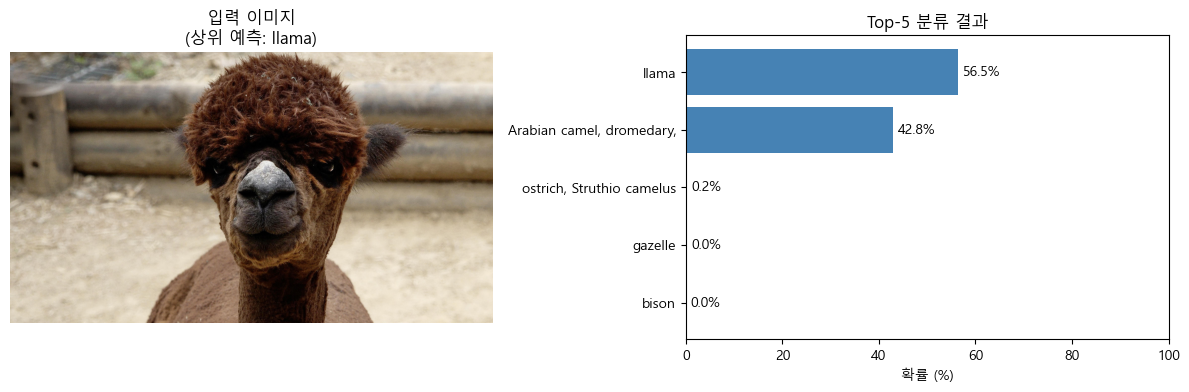

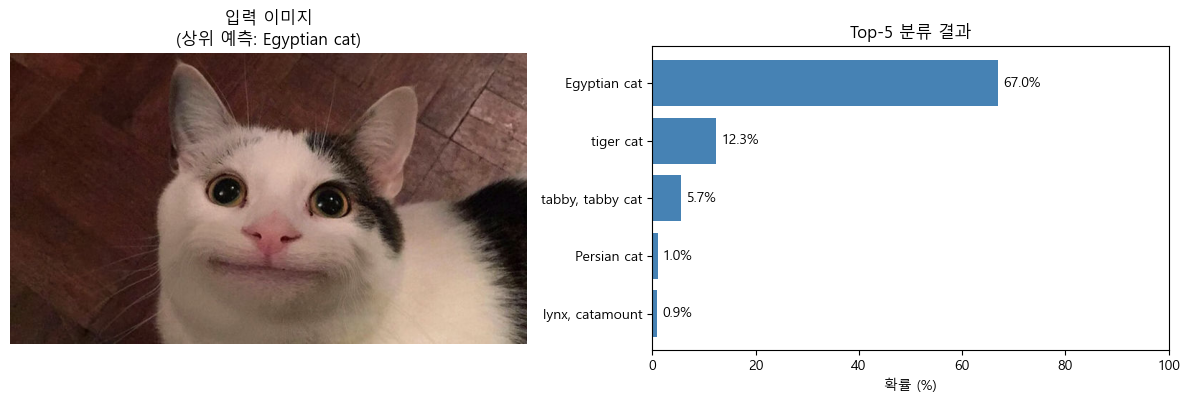

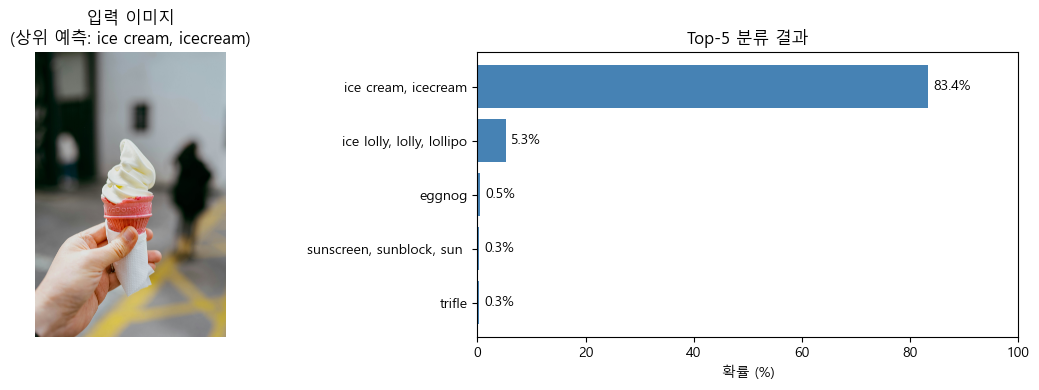

In [7]:
def classify_and_show(image_or_path):
    """이미지(경로 또는 PIL) + 분류 결과 막대그래프를 나란히 표시"""
    if isinstance(image_or_path, str):
        image = Image.open(image_or_path).convert("RGB")
    else:
        image = image_or_path.convert("RGB")

    result = classifier(image, top_k=5)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title(f"입력 이미지\n(상위 예측: {result[0]['label']})")
    axes[0].axis("off")

    labels = [r["label"][:25] for r in result]
    scores = [r["score"] * 100 for r in result]

    axes[1].barh(range(5), scores[::-1], color="steelblue")
    axes[1].set_yticks(range(5))
    axes[1].set_yticklabels(labels[::-1])
    axes[1].set_xlabel("확률 (%)")
    axes[1].set_title("Top-5 분류 결과")
    axes[1].set_xlim(0, 100)
    for i, s in enumerate(scores[::-1]):
        axes[1].text(s + 1, i, f"{s:.1f}%", va="center")

    plt.tight_layout(); plt.show()
    return result

# 샘플 시연
for fname in ["1.jpg", "2.jpg", "3.jpg"]:
    path = f"hw/image/{fname}"
    try:
        classify_and_show(path)
    except FileNotFoundError:
        print(f"⚠️ {path} 없음 — sample_images/README.md 참고")

## 셀 [4] — (Colab 전용) 파일 업로드

JupyterLab 사용자는 파일 패널에 드래그&드롭으로 충분. Colab만 아래 코드 필요.

In [5]:
# Colab에서만 실행 (로컬 JupyterLab에서는 그냥 파일을 같은 폴더에 넣으면 됨)
try:
    from google.colab import files
    uploaded = files.upload()
    print("업로드된 파일:", list(uploaded.keys()))
except ImportError:
    print("Colab 환경이 아닙니다. JupyterLab은 좌측 파일 패널에 드래그&드롭 하세요.")

Colab 환경이 아닙니다. JupyterLab은 좌측 파일 패널에 드래그&드롭 하세요.


### 셀 [4-1] — 파일 대신 웹 URL로 분류 (대안)

휴대폰 사진 옮기기가 어려운 경우. URL이 차단되면 동작하지 않을 수 있음.

In [6]:
import requests
from io import BytesIO

url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
try:
    web_img = Image.open(BytesIO(requests.get(url, timeout=10).content)).convert("RGB")
    classify_and_show(web_img)
except Exception as e:
    print(f"⚠️ URL 로드 실패: {e}")

⚠️ URL 로드 실패: cannot identify image file <_io.BytesIO object at 0x000002D43DAA5990>


## 셀 [5] — 내 사진 분류 ★

본인 사진을 같은 폴더에 두고 `my_image` 변수에 파일명을 적으세요.

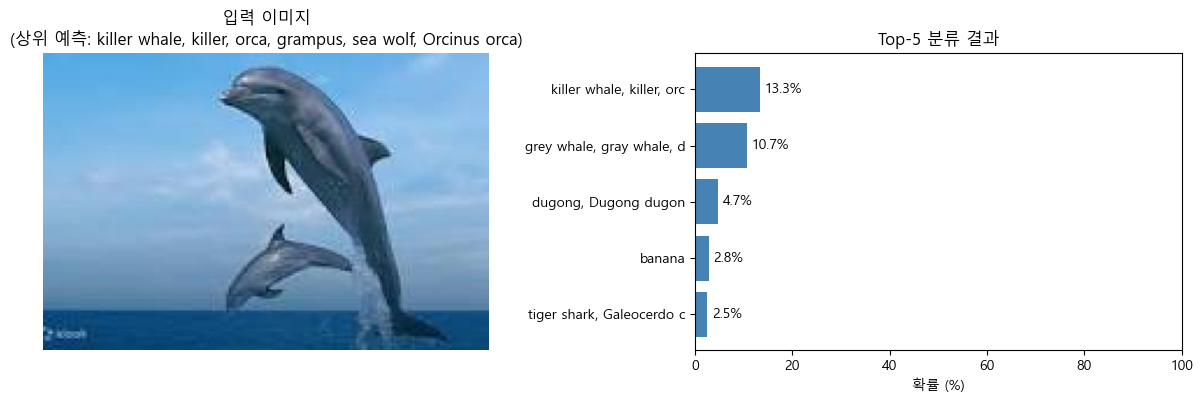


💡 ViT의 결론: 'killer whale, killer, orca, grampus, sea wolf, Orcinus orca' (확신도 13.3%)


In [7]:
import os

# TODO: 본인 사진 파일명으로 바꾸세요
my_image = "sample_images/dolphin.jpg"
#my_image = "sample_images/killerwhale.jpg"

if not os.path.exists(my_image):
    print(f"⚠️ {my_image} 가 없어서 dog.jpg로 대체 실행합니다.")
    my_image = "sample_images/dog.jpg"

result = classify_and_show(my_image)
print(f"\n💡 ViT의 결론: '{result[0]['label']}' (확신도 {result[0]['score']*100:.1f}%)")

### 셀 [5-1] — Confidence(확신도) 진단

1위 확률이 얼마면 신뢰할 만한지, Top-2가 의미적으로 가까운지 자동 판단.

In [8]:
def diagnose(result):
    top1, top2 = result[0], result[1]
    conf = top1["score"] * 100
    if conf >= 90:
        print(f"✅ 모델이 매우 확신함 ({conf:.1f}%): '{top1['label']}'")
    elif conf >= 50:
        print(f"🟡 모델이 어느정도 확신 ({conf:.1f}%): '{top1['label']}'")
        print(f"   참고로 2위는 '{top2['label']}' ({top2['score']*100:.1f}%)")
    else:
        print(f"🔴 모델이 헷갈리고 있음 (1위 {conf:.1f}%)")
        print("   상위 5개를 모두 살펴보세요 — 카테고리가 비슷하면 방향은 맞춘 것")
    print()
    for i, r in enumerate(result, 1):
        print(f"  {i}. {r['label']:35s}  {r['score']*100:.2f}%")

diagnose(result)

🔴 모델이 헷갈리고 있음 (1위 13.3%)
   상위 5개를 모두 살펴보세요 — 카테고리가 비슷하면 방향은 맞춘 것

  1. killer whale, killer, orca, grampus, sea wolf, Orcinus orca  13.31%
  2. grey whale, gray whale, devilfish, Eschrichtius gibbosus, Eschrichtius robustus  10.65%
  3. dugong, Dugong dugon                 4.70%
  4. banana                               2.84%
  5. tiger shark, Galeocerdo cuvieri      2.48%


### 셀 [5-2] — 이 모델이 아는 클래스(라벨) 확인

셀 [5]에서 돌고래를 못 맞춘 이유는 모델이 약해서가 아니라, **출력할 수 있는 라벨 목록(ImageNet-1000)에 `dolphin`이 아예 없기** 때문입니다. 정답 이름표가 없으니 가장 비슷한 `killer whale`·`grey whale`에 확률을 나눠 줄 수밖에 없습니다.

아래 `find_class()`로 **어떤 클래스가 있고 없는지 직접 검색**해 이 점을 확인합니다. 내 사진을 분류하기 전에 *"그 대상이 ImageNet에 있는 클래스인가?"* 를 먼저 확인하는 습관 → 12주차 **파인튜닝**의 동기로 이어집니다.

In [9]:
# 이 모델이 아는 클래스(라벨)는 ImageNet-1000 으로 고정 — classifier.model.config.id2label
labels = classifier.model.config.id2label
print(f"총 클래스 수: {len(labels)}개\n")


def find_class(keyword):
    """라벨에 keyword가 들어간 클래스를 모두 찾기 (대소문자 무시)"""
    kw = keyword.lower()
    hits = [(i, name) for i, name in labels.items() if kw in name.lower()]
    if hits:
        print(f"🔍 '{keyword}' 포함 클래스 {len(hits)}개:")
        for i, name in hits:
            print(f"  [{i}] {name}")
    else:
        print(f"❌ '{keyword}' 를 포함한 클래스가 없습니다 → ImageNet-1000이 모르는 대상")
    print()


# 돌고래는 '없고', 고래/상어 같은 바다 생물은 '있다'는 것을 직접 확인
find_class("dolphin")   # ❌ 없음 → 셀 [5]에서 돌고래를 못 맞춘 근본 원인
find_class("whale")     # ✅ killer whale, grey whale
find_class("shark")     # ✅ tiger shark, great white shark, hammerhead
find_class("cat")       # ✅ tabby, Egyptian cat ...

총 클래스 수: 1000개

❌ 'dolphin' 를 포함한 클래스가 없습니다 → ImageNet-1000이 모르는 대상

🔍 'whale' 포함 클래스 2개:
  [147] grey whale, gray whale, devilfish, Eschrichtius gibbosus, Eschrichtius robustus
  [148] killer whale, killer, orca, grampus, sea wolf, Orcinus orca

🔍 'shark' 포함 클래스 3개:
  [2] great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias
  [3] tiger shark, Galeocerdo cuvieri
  [4] hammerhead, hammerhead shark

🔍 'cat' 포함 클래스 16개:
  [30] bullfrog, Rana catesbeiana
  [89] sulphur-crested cockatoo, Kakatoe galerita, Cacatua galerita
  [143] oystercatcher, oyster catcher
  [281] tabby, tabby cat
  [282] tiger cat
  [283] Persian cat
  [284] Siamese cat, Siamese
  [285] Egyptian cat
  [286] cougar, puma, catamount, mountain lion, painter, panther, Felis concolor
  [287] lynx, catamount
  [358] polecat, fitch, foulmart, foumart, Mustela putorius
  [361] skunk, polecat, wood pussy
  [383] Madagascar cat, ring-tailed lemur, Lemur catta
  [387] lesser panda, red panda, panda, 

## 셀 [6] — 보너스: CIFAR-10으로 정확도 측정 → 한계 발견

ImageNet으로 학습된 ViT를 CIFAR-10에 그대로 적용하면 정확도가 떨어짐 → 12주차 파인튜닝의 동기.

In [10]:
from datasets import load_dataset

cifar_to_imagenet_keywords = {
    "airplane":   ["airliner", "warplane", "wing"],
    "automobile": ["car", "convertible", "sports car"],
    "bird":       ["bird", "robin", "magpie", "jay"],
    "cat":        ["cat", "tabby", "egyptian"],
    "deer":       ["deer", "gazelle", "elk"],
    "dog":        ["dog", "retriever", "spaniel", "terrier"],
    "frog":       ["frog", "toad", "bullfrog"],
    "horse":      ["horse", "pony", "stallion"],
    "ship":       ["ship", "boat", "liner", "yacht"],
    "truck":      ["truck", "trailer", "pickup"],
}

ds = load_dataset("uoft-cs/cifar10")
label_names = ds["test"].features["label"].names

samples = ds["test"].select(range(100))

correct = 0
for item in samples:
    img_i = item["img"].convert("RGB")
    true_label = label_names[item["label"]]
    pred = classifier(img_i, top_k=5)
    pred_labels = [p["label"].lower() for p in pred]

    is_match = any(
        any(kw in pl for pl in pred_labels)
        for kw in cifar_to_imagenet_keywords[true_label]
    )
    if is_match:
        correct += 1

print(f"CIFAR-10 100장 중 매칭: {correct}/100  ({correct}%)")
print("→ 다음 주 파인튜닝(12주차)에서 이 정확도를 끌어올립니다.")

CIFAR-10 100장 중 매칭: 72/100  (72%)
→ 다음 주 파인튜닝(12주차)에서 이 정확도를 끌어올립니다.


### 셀 [6-1] — 72%는 정말 높은 걸까? (엄격 top-1 vs 관대 top-5)

셀 [6]의 72%는 **표준 정확도가 아닙니다.** 매칭 기준이 ① **top-5**(1~5등 중 하나만 맞아도 정답)이고 ② 키워드 **부분 문자열**이라 매우 후합니다. 실제로 모델을 쓸 때 보는 건 **1등(top-1)** 하나뿐이죠.

아래 셀은 **같은 키워드 규칙**을 쓰되 *보는 등수만* 바꿔 두 기준을 나란히 측정합니다. 보통 **top-1은 top-5보다 눈에 띄게 낮게** 나옵니다. 그 차이가 "2~5등까지 봐준 보너스"이고, 파인튜닝(12주차)이 끌어올려야 할 진짜 격차입니다.

> 참고 ① 표본이 100장뿐이라 오차가 큽니다(±9%p 수준) → 숫자는 "대략 ○○%대"로 해석.
> 참고 ② 키워드 사전이 불완전해(예: `bird`에 `junco` 미포함) 맞게 맞힌 것도 오답 처리될 수 있어, 두 숫자 모두 진짜 정확도의 *근사치*입니다.

In [11]:
# ⚠️ 셀 [6]을 먼저 실행하세요 (samples, cifar_to_imagenet_keywords, label_names 재사용)
#
# 같은 '키워드 매칭' 규칙을 쓰되, 보는 등수만 다르게 두 기준을 함께 측정:
#   - 엄격(top-1): 1등 예측만 정답으로 인정 → 실제 모델을 쓸 때 보는 진짜 기준
#   - 관대(top-5): 1~5등 중 하나만 맞아도 인정 → 셀 [6]이 쓴 후한 기준
# 바뀌는 변수가 'top-1 vs top-5' 하나뿐이라, 두 숫자의 차이 = 'top-5로 봐준 보너스'

def matches(pred_labels, true_label):
    """pred_labels 중 하나라도 정답 키워드를 (부분 문자열로) 포함하면 True"""
    return any(
        any(kw in pl for pl in pred_labels)
        for kw in cifar_to_imagenet_keywords[true_label]
    )

top1_correct = 0
top5_correct = 0
for item in samples:
    img_i = item["img"].convert("RGB")
    true_label = label_names[item["label"]]
    pred_labels = [p["label"].lower() for p in classifier(img_i, top_k=5)]

    if matches(pred_labels[:1], true_label):   # 1등만
        top1_correct += 1
    if matches(pred_labels, true_label):       # 1~5등
        top5_correct += 1

n = len(samples)
print(f"엄격 기준 (top-1만): {top1_correct}/{n}  ({top1_correct/n*100:.0f}%)")
print(f"관대 기준 (top-5)  : {top5_correct}/{n}  ({top5_correct/n*100:.0f}%)")
print(f"→ 차이 {(top5_correct - top1_correct)/n*100:.0f}%p 는 '2~5등까지 봐준' 보너스입니다.")
print("→ 실제로 쓸 때 보는 건 1등(top-1). 파인튜닝(12주차)으로 이 top-1을 ~98%까지 끌어올립니다.")

엄격 기준 (top-1만): 40/100  (40%)
관대 기준 (top-5)  : 72/100  (72%)
→ 차이 32%p 는 '2~5등까지 봐준' 보너스입니다.
→ 실제로 쓸 때 보는 건 1등(top-1). 파인튜닝(12주차)으로 이 top-1을 ~98%까지 끌어올립니다.


## 셀 [7] — (선택) ViT의 Attention 시각화

모델이 이미지의 어느 부분에 집중했는지 시각화 — ViT만의 해석성.

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 6881.04it/s]


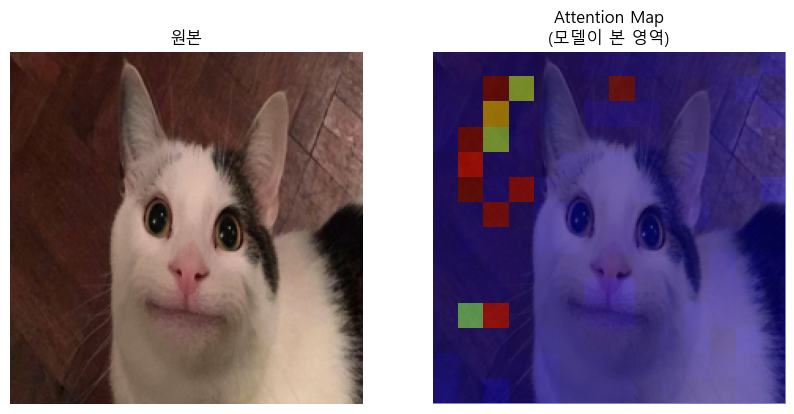

In [8]:
from transformers import ViTImageProcessor, ViTForImageClassification

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224", output_attentions=True
)
model.eval()

vit_img = Image.open("hw/image/2.jpg").convert("RGB")
inputs = processor(images=vit_img, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

attn = outputs.attentions[-1]
attn = attn[0].mean(0)
cls_attn = attn[0, 1:]
attn_map = cls_attn.reshape(14, 14).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(vit_img.resize((224, 224)))
axes[0].set_title("원본"); axes[0].axis("off")
axes[1].imshow(vit_img.resize((224, 224)))
axes[1].imshow(attn_map, cmap="jet", alpha=0.5,
               extent=(0, 224, 224, 0))
axes[1].set_title("Attention Map\n(모델이 본 영역)"); axes[1].axis("off")
plt.show()

### 셀 [7-1] — (개선) Attention Rollout 시각화

셀 [7]의 결과를 보면 빨강·노랑 핫스팟이 강아지 얼굴이 아니라 **배경·가장자리**에 쏠려 있습니다. 이는 버그가 아니라, **지도학습 ViT의 마지막 층 raw attention**이 갖는 한계입니다.
- **마지막 층 한 개**만 봐서 노이즈가 큼
- ViT가 정보량 적은 **배경 패치를 전역 정보 저장용(레지스터)으로** 써버림 (*ViTs Need Registers*, 2023)

**Attention Rollout**(Abnar & Zuidema, 2020)은 **모든 층의 attention을 누적**하고 residual 연결까지 반영해, 물체(강아지)에 훨씬 잘 모이는 맵을 만듭니다. 아래 셀에서 **원본 · 기존 방식 · 개선 방식**을 나란히 비교합니다.

> ⚠️ **셀 [7]을 먼저 실행**한 뒤 이 셀을 실행하세요 — `outputs`, `vit_img`, `attn_map`을 재사용합니다.

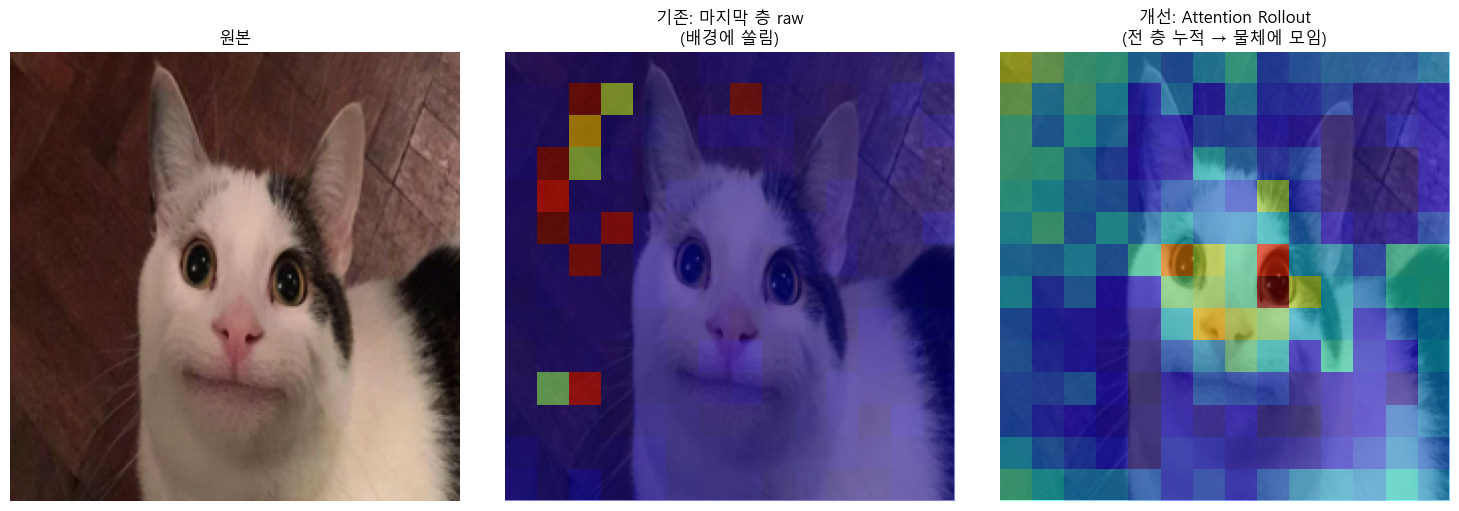

In [9]:
# ⚠️ 셀 [7]을 먼저 실행한 뒤 이 셀을 실행하세요 (outputs, vit_img, attn_map 재사용)
#
# Attention Rollout (Abnar & Zuidema, 2020)
# - 셀 [7]: '마지막 층 raw attention'만 봐서 배경/가장자리 패치에 쏠림
# - 여기: '모든 층 attention을 누적' + residual 연결(+I) 반영 → 물체에 더 잘 모임

# 1) 층별로 head 평균: outputs.attentions = (층 수)개 × [1, heads, 197, 197]
atts = [a[0].mean(0) for a in outputs.attentions]      # 각 원소 [197, 197]
n_tokens = atts[0].shape[-1]                            # 197 = [CLS] 1개 + 패치 196개

# 2) residual 연결 반영(A+I) 후 행 정규화하고, 모든 층을 누적해서 곱
rollout = torch.eye(n_tokens)
for a in atts:
    a_hat = a + torch.eye(n_tokens)
    a_hat = a_hat / a_hat.sum(dim=-1, keepdim=True)     # 각 행 합 = 1
    rollout = a_hat @ rollout                           # 층을 차례로 누적

# 3) [CLS](0번) → 패치(1:) 누적 attention → 14×14 맵, 0~1 정규화(대비 향상)
cls_rollout = rollout[0, 1:]
rollout_map = cls_rollout.reshape(14, 14).detach().numpy()
rollout_map = (rollout_map - rollout_map.min()) / (rollout_map.max() - rollout_map.min() + 1e-8)

# 4) 원본 · 기존(셀 [7]) · 개선(rollout) 3개를 나란히 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(vit_img.resize((224, 224)))
axes[0].set_title("원본"); axes[0].axis("off")

axes[1].imshow(vit_img.resize((224, 224)))
axes[1].imshow(attn_map, cmap="jet", alpha=0.5, extent=(0, 224, 224, 0))
axes[1].set_title("기존: 마지막 층 raw\n(배경에 쏠림)"); axes[1].axis("off")

axes[2].imshow(vit_img.resize((224, 224)))
axes[2].imshow(rollout_map, cmap="jet", alpha=0.5, extent=(0, 224, 224, 0))
axes[2].set_title("개선: Attention Rollout\n(전 층 누적 → 물체에 모임)"); axes[2].axis("off")

plt.tight_layout(); plt.show()

## 셀 [8] — (도전) 다른 비전 모델과 비교

ViT 외에 ResNet·ConvNeXt·Swin Transformer로 같은 사진을 분류.
모델마다 결과가 살짝 다른 것을 확인 — 앙상블의 출발점.

In [12]:
models_to_try = [
    "google/vit-base-patch16-224",
    "microsoft/resnet-50",
    "facebook/convnext-base-224",
    "microsoft/swin-base-patch4-window7-224",
]

compare_img = Image.open("sample_images/dog.jpg").convert("RGB")
for model_name in models_to_try:
    try:
        clf = pipeline("image-classification", model=model_name, device=device)
        top1 = clf(compare_img)[0]
        print(f"{model_name:50s}  →  {top1['label']:30s}  ({top1['score']*100:.1f}%)")
    except Exception as e:
        print(f"{model_name:50s}  →  로드 실패 ({type(e).__name__})")

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


google/vit-base-patch16-224                         →  Labrador retriever              (97.7%)


C:\Users\white\Desktop\강의\동양\빅데이터분석프로젝트\BigDataAnalysis\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\white\.cache\huggingface\hub\models--microsoft--resnet-50. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Using a slow image processor as `use_fast` is unset and a slow processor was saved with 

microsoft/resnet-50                                 →  Labrador retriever              (99.8%)


C:\Users\white\Desktop\강의\동양\빅데이터분석프로젝트\BigDataAnalysis\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\white\.cache\huggingface\hub\models--facebook--convnext-base-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Device set to use cpu


facebook/convnext-base-224                          →  Labrador retriever              (94.8%)


C:\Users\white\Desktop\강의\동양\빅데이터분석프로젝트\BigDataAnalysis\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\white\.cache\huggingface\hub\models--microsoft--swin-base-patch4-window7-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Device set to use cpu


microsoft/swin-base-patch4-window7-224              →  Labrador retriever              (94.3%)


---
## 3교시 마무리 체크리스트

- [ ] 셀 [1]에서 ViT 모델을 1줄로 로드했다.
- [ ] 셀 [2]에서 강아지 사진의 top-5를 출력했다.
- [ ] 셀 [5]에서 본인 사진을 분류하고 결과를 해석했다.
- [ ] 셀 [5-1]에서 Confidence를 기준으로 모델의 확신도를 판단했다.
- [ ] 셀 [6]에서 CIFAR-10 정확도가 ImageNet보다 떨어지는 것을 확인했다.

## 과제: "내 사진 10장 분류 도전기"

1. 본인 사진 **10장 이상** 준비 (동물·음식·풍경·사물 등 다양하게)
2. 각 사진을 `classify_and_show()`로 분류
3. **잘 분류된 사례 3개 + 잘못 분류된 사례 3개** 정리
4. 각 사례에 대해 "왜 이렇게 분류됐을까?" 2~3줄 본인 생각
5. 종합 소감 5줄 이상

**다음 시간(12주차) 예고**: ViT를 우리 데이터(CIFAR-10)에 맞게 **파인튜닝(Fine-tuning)** 합니다.